# INSID3 medical benchmark

Training-free in-context segmentation on three domains INSID3 has not been scored on: **colon polyp** ([Kvasir-SEG](#ref-jha2020)), **kidney tumor** ([KiPA22](#ref-he2021)), **cardiac LV** ([ACDC](#ref-bernard2018)). The project asks whether the published medical result holds on these domains, whether a medical-pretrained encoder improves one-shot INSID3, and how far that number still sits behind medically supervised MedSAM2.

This project has three aims.

1. **Transfer.** Does INSID3 remain a strong training-free one-shot method when the domain is no longer ISIC or chest X-ray — endoscopy, abdominal CT, and cardiac MRI, with targets that range from well-outlined anatomy to small, appearance-defined lesions? “Strong” is measured against Matcher and GF-SAM on the same episodes, and against the paper anchors: ISIC **54.4** mIoU and CXR lung **78.8** mIoU ([Cuttano et al., CVPR 2026](#ref-cuttano2026)).
2. **Encoder.** On kidney tumor CT, does replacing DINOv3 with a CT-pretrained frozen encoder (FlexiCT-2D) raise one-shot mIoU?
3. **Supervision gap.** How far is that training-free number from box-prompted MedSAM2 zero-shot on the same slices? That comparison is a reference, not a same-paradigm contest.

The evaluation protocol follows the INSID3's lung and ISIC experiments:

- 600 independently sampled one-shot episodes per domain
- For reproducibility, episode sampling held fixed
- DINOv3 ViT-L with input resolution 768 px
- INSID default inference settings (τ = 0.6, α = 0.2, s = 500), with no per-domain hyperparameter tuning

## Table of contents

0. [Setup](#sec-setup)
1. [Download / preprocess benchmark datasets](#sec-data)
2. [Run in-context evaluation](#sec-eval)
3. [Results](#sec-report)
4. [Browse one domain (interactive)](#sec-inspect)
5. [References](#sec-refs)

<h2 id="sec-setup">0. Setup</h2>

In [1]:
REPO_URL = "https://github.com/gary8564/insid3-medical-benchmark.git"
DRIVE_ROOT = "/content/drive/MyDrive/insid3-medical-benchmark"
REPO_DIR = "/content/insid3-medical-benchmark"
MODEL_SIZE = "large"
IMAGE_SIZE = 768
SEED = 0
PREVIEW = None  # e.g. 8 to test the pipeline; None = all 600
VIT_L = "dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth"
DOMAINS = ("polyp", "kidney_tumor", "cardiac")

In [3]:
from google.colab import drive

drive.mount("/content/drive")

from pathlib import Path

drive_root = Path(DRIVE_ROOT)
for sub in ("processed", "pretrain", "results"):
    (drive_root / sub).mkdir(parents=True, exist_ok=True)
print("Drive layout:", drive_root)
print("ViT-L present:", (drive_root / "pretrain" / VIT_L).is_file())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive layout: /content/drive/MyDrive/insid3-medical-benchmark
ViT-L present: True


In [4]:
from pathlib import Path

repo = Path(REPO_DIR)
if not (repo / ".git").is_dir():
    !git clone --recurse-submodules {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull --ff-only
    !git -C {REPO_DIR} submodule update --init --recursive

assert (repo / "third_party" / "INSID3" / "models" / "insid3.py").is_file(), (
    f"INSID3 submodule missing at {repo / 'third_party' / 'INSID3'}; clone with --recurse-submodules"
)
%cd {REPO_DIR}

Cloning into '/content/insid3-medical-benchmark'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 69 (delta 15), reused 65 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 74.63 KiB | 1.62 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Submodule 'third_party/INSID3' (https://github.com/visinf/INSID3.git) registered for path 'third_party/INSID3'
Cloning into '/content/insid3-medical-benchmark/third_party/INSID3'...
remote: Enumerating objects: 163, done.        
remote: Counting objects: 100% (61/61), done.        
remote: Compressing objects: 100% (31/31), done.        
remote: Total 163 (delta 42), reused 30 (delta 30), pack-reused 102 (from 1)        
Receiving objects: 100% (163/163), 15.79 MiB | 34.85 MiB/s, done.
Resolving deltas: 100% (78/78), done.
Submodule path 'third_party/INSID3': checked out '0c165a10cf52ab91f335883d06260de86854adbe'
/content/insid3-m

In [5]:
# Colab already has torch, numpy, pillow, matplotlib, tqdm, scikit-learn.
# Do not `uv sync` or `uv pip install .[torch]`: pyproject pins CPython 3.10
# and would download a second torch on top of the runtime CUDA build.
%pip install -q uv
!uv pip install --system -q nibabel einops huggingface_hub pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 113.2 MB/s eta 0:00:0000:0100:01


<div style="background:#fff8e1;border-left:4px solid #f9a825;padding:0.8em 1em;margin:1em 0;color:#4a3c00;">
<strong>⚠️ DINOv3 access required</strong>. INSID3 uses a frozen DINOv3 encoder. Request a grant at <a href="https://github.com/facebookresearch/dinov3" style="color:#4a3c00;"><strong>facebookresearch/dinov3</strong></a>. Weights are gated and are not in this repo.
</div>

After approval, download **ViT-L** and place it in `pretrain/` at the repo root `pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth`

In [6]:
from pathlib import Path

# pretrain/ is gitignored, so the clone does not create it. curl cannot.
drive_weights = Path(DRIVE_ROOT) / "pretrain" / VIT_L
repo_weights = Path(REPO_DIR) / "pretrain" / VIT_L
repo_weights.parent.mkdir(parents=True, exist_ok=True)
drive_weights.parent.mkdir(parents=True, exist_ok=True)

# Prefer an existing Drive copy (survives Colab runtime resets).
if drive_weights.is_file() and drive_weights.stat().st_size > 0:
    print("using Drive weights:", drive_weights, drive_weights.stat().st_size)
else:
    # Write to local disk first — Drive FUSE often fails mid-curl on ~1.1 GB files.
    !curl -L --fail --retry 3 --output {repo_weights} "https://dinov3.llamameta.net/dinov3_vitl16/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoid25uZnl5cHUxb3Z0NWlza3hieXpmZzY3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3ODY3OTc2MTF9fX1dfQ__&Signature=pdJdVI46bVY7BpoCVj3Yi-c0GrOmusbgQ2QuQiFDRvhfXF1baD0EvSKkKqL3MDZoG70k8xJ7-kcTRYlL4y29dciSE%7EqasX0v5GPGMqIrQ7qOH2V0JVwQ-OX79V6n0X-B2SZKdlLZkSd%7E89iMnOOj9btMd30me4s1Vk%7ERjvYfhwwdHv7WxvRSKrmq6YLguhzxgw8%7EhITJuiju2ImwEjj47OJOs4SHCQxPS0QRcqIoC5sBHcYtRQg9gr%7E5frdwGyJxJa0JK3E91OdZt8PzoTQXzqgSbeY9feSukZiAb1YXY%7EeBHSLqqSqMZGTZtJ-mzPSfY3p98mRJI%7ET1SJROidqTAQ__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=1052263980722882"
    assert repo_weights.is_file() and repo_weights.stat().st_size > 1_000_000_000, repo_weights
    print("copying to Drive (keeps weights after runtime reset)...")
    import shutil
    shutil.copy2(repo_weights, drive_weights)

if not repo_weights.is_file():
    if repo_weights.exists() or repo_weights.is_symlink():
        repo_weights.unlink()
    repo_weights.symlink_to(drive_weights)
print("using", repo_weights, "size", repo_weights.stat().st_size)

using Drive weights: /content/drive/MyDrive/insid3-medical-benchmark/pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth 1213050671
using /content/insid3-medical-benchmark/pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth size 1213050671


In [7]:
from pathlib import Path

weights = Path(REPO_DIR) / "pretrain" / VIT_L
assert weights.is_file() and weights.stat().st_size > 0, (
    f"Missing {weights}. After DINOv3 access is granted, place {VIT_L} in pretrain/."
)
print("using", weights)

using /content/insid3-medical-benchmark/pretrain/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth


<h2 id="sec-data">1. Download / preprocess benchmark datasets</h2>

Build the 2D cache used for in-context eval:

- **[Kvasir-SEG](#ref-jha2020)** is a 2D colonoscopy set with paired polyp masks.
- **[KiPA22](#ref-he2021)** is a 3D abdominal CT challenge with kidney, vessels, and tumor labels.
- **[ACDC](#ref-bernard2018)** is a 3D cine cardiac MRI challenge with RV, myocardium, and LV cavity labels.

[Kvasir-SEG](#ref-jha2020) is already 2D, so each endoscopy frame is kept with its binary polyp mask. [KiPA22](#ref-he2021) and [ACDC](#ref-bernard2018) are volumes, so each case is preprocessed to one image–mask PNG.

For [KiPA22](#ref-he2021), the axial slice with the **most tumor** voxels (other structures become background) is kept. For [ACDC](#ref-bernard2018), end-diastole is read from `Info.cfg`, then the short-axis slice with the **largest LV cavity**.

<div style="background:#fff8e1;border-left:4px solid #f9a825;padding:0.8em 1em;margin:1em 0;color:#4a3c00;">
<strong>⚠️ Hugging Face login required</strong> for [KiPA22](#ref-he2021) and [ACDC](#ref-bernard2018).
</div>

In [8]:
from huggingface_hub import login, notebook_login
import os

# Uses Colab secrets if you added HF_TOKEN; otherwise a login prompt.
try:
    from google.colab import userdata
    login(token=userdata.get("hf_token"))
except Exception:
    notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


In [9]:
from src.datasets.pairing import IMAGE_EXTENSIONS

processed = Path(DRIVE_ROOT) / "processed"

def _n_images(domain: str) -> int:
    folder = processed / domain / "images"
    if not folder.is_dir():
        return 0
    return sum(
        1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

In [10]:
from pathlib import Path

missing = [name for name in DOMAINS if _n_images(name) == 0]
print("missing domains:", missing or "none")
if missing:
    processed_root = str(processed)
    datasets = " ".join(missing)
    !python src/data/prepare.py --processed-root {processed_root} --datasets {datasets}

missing domains: none


In [11]:
from pathlib import Path
import shutil

processed = Path(DRIVE_ROOT) / "processed"
counts = {name: _n_images(name) for name in DOMAINS}
for name, n in counts.items():
    print(f"{name}: {n} images")

assert counts["polyp"] >= 900, (
    "polyp cache empty — Kvasir images are .jpg, not .png. "
    "Re-run prepare only if Drive processed/polyp/images is actually empty."
)
assert counts["kidney_tumor"] >= 70, "kidney_tumor cache empty — re-run prepare (needs HF login)."
assert counts["cardiac"] >= 100, "cardiac cache empty — re-run prepare (needs HF login)."

raw = Path(REPO_DIR) / "data" / "raw"
if raw.exists():
    shutil.rmtree(raw)
    print("removed local raw downloads; processed cache is on Drive")

polyp: 1000 images
kidney_tumor: 70 images
cardiac: 100 images


<h2 id="sec-eval">2. Run in-context evaluation</h2>

In [12]:
import json
from pathlib import Path

for dataset in DOMAINS:
    log = f"/tmp/insid3_episodes_{dataset}.json"
    !python src/run_insid3.py --dataset {dataset} \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {DRIVE_ROOT}/results \
      --dry-run > {log}
    episodes_path = Path(DRIVE_ROOT) / "results" / dataset / "episodes.json"
    n = len(json.loads(episodes_path.read_text())) if episodes_path.is_file() else 0
    print(f"{dataset}: {n} episodes → {episodes_path}")

polyp: 600 episodes → /content/drive/MyDrive/insid3-medical-benchmark/results/polyp/episodes.json
kidney_tumor: 600 episodes → /content/drive/MyDrive/insid3-medical-benchmark/results/kidney_tumor/episodes.json
cardiac: 600 episodes → /content/drive/MyDrive/insid3-medical-benchmark/results/cardiac/episodes.json


In [13]:
import json
from pathlib import Path

# False: skip a domain whose metrics.json already matches this protocol.
# True: run inference again even if the results under the same evaluation settings exist.
OVERWRITE = False

preview = f"--preview {PREVIEW}" if PREVIEW is not None else ""
expected_n = PREVIEW if PREVIEW is not None else 600


def _is_complete(name: str) -> bool:
    path = Path(DRIVE_ROOT) / "results" / name / "metrics.json"
    if not path.is_file():
        return False
    row = json.loads(path.read_text())
    return (
        int(row.get("n", 0)) == int(expected_n)
        and row.get("model_size") == MODEL_SIZE
        and int(row.get("image_size", 0)) == int(IMAGE_SIZE)
        and int(row.get("seed", -1)) == int(SEED)
    )


for dataset in DOMAINS:
    path = Path(DRIVE_ROOT) / "results" / dataset / "metrics.json"
    if _is_complete(dataset) and not OVERWRITE:
        row = json.loads(path.read_text())
        print(f"{dataset}: skip (n={row['n']}  mIoU={row['mIoU']:.3f}  → {path})")
        continue
    log = f"/tmp/insid3_eval_{dataset}.log"
    print(f"{dataset}: running → {log}")
    !python src/run_insid3.py --dataset {dataset} \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {DRIVE_ROOT}/results \
      --model-size {MODEL_SIZE} --image-size {IMAGE_SIZE} --seed {SEED} --device cuda \
      {preview} > {log}
    row = json.loads(path.read_text())
    print(
        f"{dataset}: n={row['n']}  mIoU={row['mIoU']:.3f}  "
        f"Dice={row['Dice']:.3f}  → {path}"
    )

print("\nDrive cache:")
for name in DOMAINS:
    path = Path(DRIVE_ROOT) / "results" / name / "metrics.json"
    if not path.is_file():
        print(f"  {name}: missing")
        continue
    row = json.loads(path.read_text())
    print(f"  {name}: n={row['n']}  mIoU={row['mIoU']:.3f}  Dice={row['Dice']:.3f}")

polyp: skip (n=600  mIoU=0.677  → /content/drive/MyDrive/insid3-medical-benchmark/results/polyp/metrics.json)
kidney_tumor: skip (n=600  mIoU=0.309  → /content/drive/MyDrive/insid3-medical-benchmark/results/kidney_tumor/metrics.json)
cardiac: running → /tmp/insid3_eval_cardiac.log
100% 1.13G/1.13G [00:18<00:00, 66.8MB/s]
cardiac: 100% 600/600 [03:27<00:00,  2.90it/s]
cardiac: n=600  mIoU=0.119  Dice=0.200  → /content/drive/MyDrive/insid3-medical-benchmark/results/cardiac/metrics.json

Drive cache:
  polyp: n=600  mIoU=0.677  Dice=0.761
  kidney_tumor: n=600  mIoU=0.309  Dice=0.437
  cardiac: n=600  mIoU=0.119  Dice=0.200


<h2 id="sec-report">3. Results</h2>

One-shot INSID3 with frozen DINOv3. These tasks are not clinical equivalents of INSID paper’s ISIC or chest X-ray experiments.

| Domain | Image | Target |
|---|---|---|
| Colon polyp ([Kvasir-SEG](#ref-jha2020)) | endoscopy | mucosal lesion |
| Kidney tumor ([KiPA22](#ref-he2021)) | axial CT | small tumor focus |
| Cardiac LV ([ACDC](#ref-bernard2018)) | short-axis cine MRI | LV cavity |

**Scores.** Polyp is highest, kidney tumor is in the middle, cardiac LV is lowest — the large chamber is the failure case, not the easy one. That is unlikely to be a size effect (the LV cavity is large). A short-axis frame contains two blood pools (LV and RV); a one-shot reference from another patient may not tell the model which chamber to follow. Endoscopy is also closer to DINOv3’s natural-image pretraining than cine MRI. Check the worst-case overlays: empty mask, right ventricle, or whole heart instead of LV.

In [15]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.datasets.episodes import load_paired_index

DOMAIN_META = {
    "polyp": {"title": "Colon polyp", "modality": "endoscopy"},
    "kidney_tumor": {"title": "Kidney tumor", "modality": "CT"},
    "cardiac": {"title": "Cardiac LV", "modality": "MRI"},
}
HEADLINE = {"seed": 0, "model_size": "large", "image_size": 768, "n": 600}
GT_GREEN = (0.15, 0.8, 0.35)
PRED_BLUE = (0.2, 0.45, 0.95)

results_root = Path(DRIVE_ROOT) / "results"
processed_root = Path(DRIVE_ROOT) / "processed"
fig_dir = results_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)


def _overlay(image, mask, color):
    out = image.astype(np.float32).copy()
    tint = np.array(color, dtype=np.float32) * 255.0
    out[mask] = 0.55 * out[mask] + 0.45 * tint
    return np.clip(out, 0, 255).astype(np.uint8)


def _spearman(x, y):
    """Rank correlation: does IoU rise when the target is larger?"""
    if len(x) < 3:
        return float("nan")
    rx = np.argsort(np.argsort(x))
    ry = np.argsort(np.argsort(y))
    return float(np.corrcoef(rx.astype(float), ry.astype(float))[0, 1])


def _load_domain(name):
    path = results_root / name / "metrics.json"
    if not path.is_file():
        return None
    payload = json.loads(path.read_text())
    items = list(payload.get("items") or [])
    ious = np.array([float(row["IoU"]) for row in items], dtype=float)
    flags = [
        f"{key}={payload.get(key) if key != 'n' else int(payload.get('n', len(items)))} (expected {expected})"
        for key, expected in HEADLINE.items()
        if (int(payload.get("n", len(items))) if key == "n" else payload.get(key)) != expected
    ]
    return {
        "payload": payload,
        "items": items,
        "ious": ious,
        "ranked": sorted(items, key=lambda row: row["IoU"], reverse=True),
        "flags": flags,
    }


def _show_triple(name, row, pairs, caption):
    pred_path = results_root / name / "preds" / f"{int(row['episode_index']):04d}_{row['target_id']}.png"
    ref_img, ref_mask = pairs[row["reference_id"]]
    tgt_img, tgt_mask = pairs[row["target_id"]]
    ref_np = np.array(Image.open(ref_img).convert("RGB"))
    tgt_np = np.array(Image.open(tgt_img).convert("RGB"))
    ref_gt = np.array(Image.open(ref_mask).convert("L")) > 0
    gt = np.array(Image.open(tgt_mask).convert("L")) > 0
    pred = np.array(Image.open(pred_path).convert("L")) > 0 if pred_path.is_file() else np.zeros_like(gt)
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
    axes[0].imshow(_overlay(ref_np, ref_gt, GT_GREEN))
    axes[0].set_title("Reference + mask")
    axes[1].imshow(_overlay(tgt_np, gt, GT_GREEN))
    axes[1].set_title("Target + GT")
    axes[2].imshow(_overlay(tgt_np, pred, PRED_BLUE))
    axes[2].set_title("Target + prediction")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{DOMAIN_META[name]['title']} ({caption} IoU = {row['IoU']:.3f})", fontsize=11)
    fig.savefig(fig_dir / f"{name}_{caption}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


domains = {name: _load_domain(name) for name in DOMAINS}
found = [name for name, row in domains.items() if row is not None]
missing = [name for name in DOMAINS if domains[name] is None]
if missing:
    print("Missing:", ", ".join(missing), ". Run section 2 first.")
if not found:
    raise FileNotFoundError(f"no metrics.json under {results_root}")

print(f"{'domain':<16} {'n':>5} {'mIoU':>7} {'Dice':>7} {'median':>7}")
for name in found:
    row = domains[name]
    p = row["payload"]
    print(
        f"{DOMAIN_META[name]['title']:<16} {int(p['n']):5d} "
        f"{100 * p['mIoU']:6.1f}  {100 * p['Dice']:6.1f}  {100 * np.median(row['ious']):6.1f}"
    )
for name in found:
    if domains[name]["flags"]:
        print(f"protocol {name}:", "; ".join(domains[name]["flags"]))

domain               n    mIoU    Dice  median
Colon polyp        600   67.7    76.1    81.4
Kidney tumor       600   30.9    43.7    28.1
Cardiac LV         600   11.9    20.0     7.6


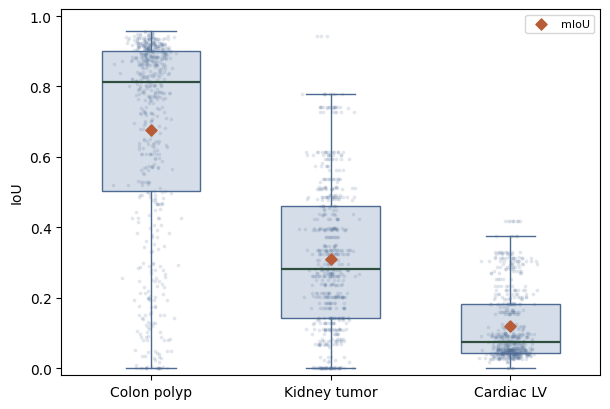

In [18]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
data = [domains[name]["ious"] for name in found]
ax.boxplot(
    data,
    tick_labels=[DOMAIN_META[name]["title"] for name in found],
    whis=1.5,
    showfliers=False,
    patch_artist=True,
    widths=0.55,
    medianprops={"color": "#2F4F3E", "linewidth": 1.6},
    boxprops={"facecolor": "#D5DDE8", "edgecolor": "#4C6A92"},
    whiskerprops={"color": "#4C6A92"},
    capprops={"color": "#4C6A92"},
)
rng = np.random.default_rng(0)
for i, name in enumerate(found, start=1):
    ious = domains[name]["ious"]
    ax.scatter(rng.normal(i, 0.055, size=len(ious)), ious, s=7, alpha=0.16, c="#4C6A92", linewidths=0, zorder=2)
    ax.scatter([i], [float(np.mean(ious))], marker="D", s=32, c="#B85C38", zorder=3, label="mIoU" if i == 1 else None)
ax.set_ylabel("IoU")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8, frameon=True, loc="upper right")
fig.tight_layout()
fig.savefig(fig_dir / "iou_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

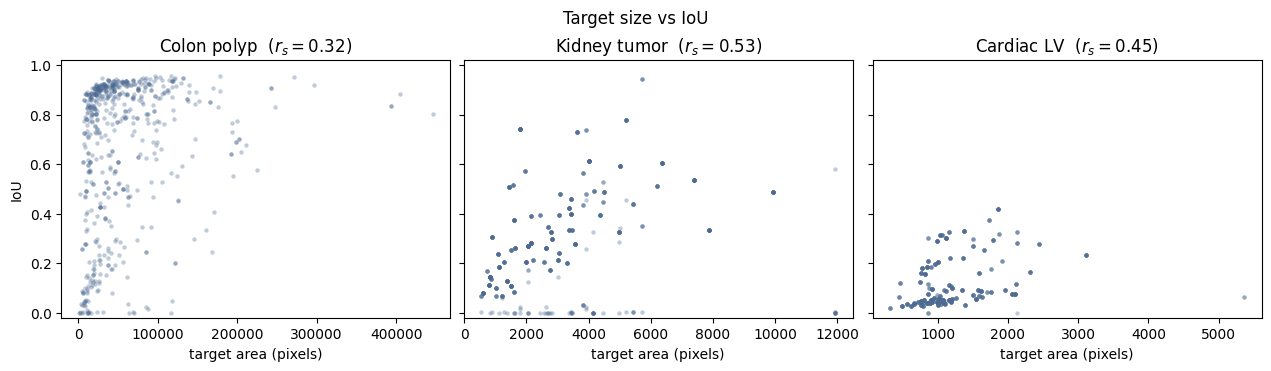

In [19]:
fig, axes = plt.subplots(1, len(found), figsize=(4.2 * len(found), 3.6), constrained_layout=True, sharey=True)
if len(found) == 1:
    axes = [axes]
for ax, name in zip(axes, found):
    pairs = load_paired_index(processed_root, name)
    areas = np.array(
        [(np.array(Image.open(pairs[item["target_id"]][1]).convert("L")) > 0).sum() for item in domains[name]["items"]],
        dtype=float,
    )
    ious = domains[name]["ious"]
    ax.scatter(areas, ious, s=10, alpha=0.35, c="#4C6A92", linewidths=0)
    ax.set_title(fr"{DOMAIN_META[name]['title']}  ($r_s={_spearman(areas, ious):.2f}$)")
    ax.set_xlabel("target area (pixels)")
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("IoU")
fig.suptitle("Target size vs IoU", fontsize=12)
fig.savefig(fig_dir / "iou_vs_gt_area.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

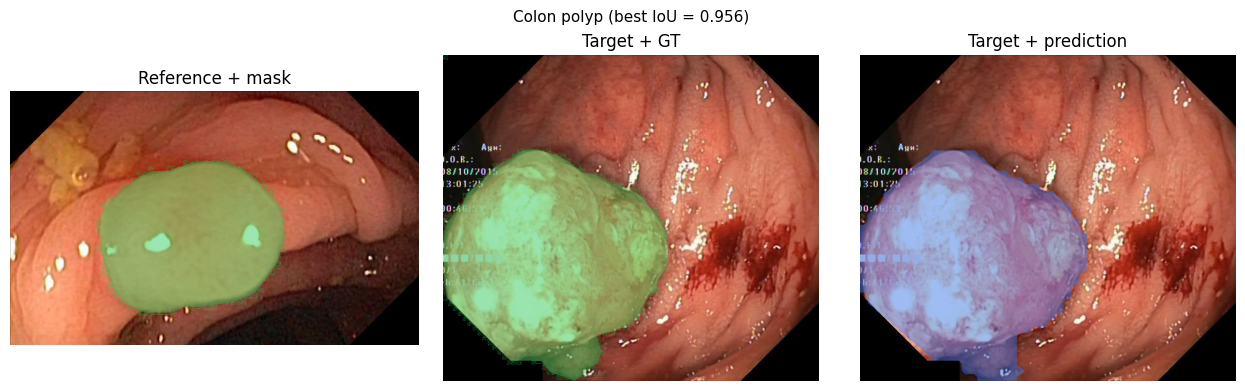

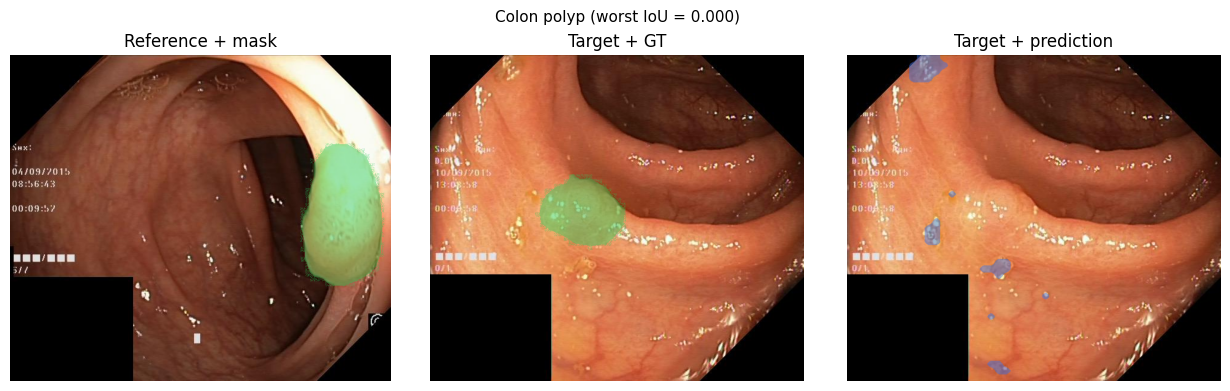

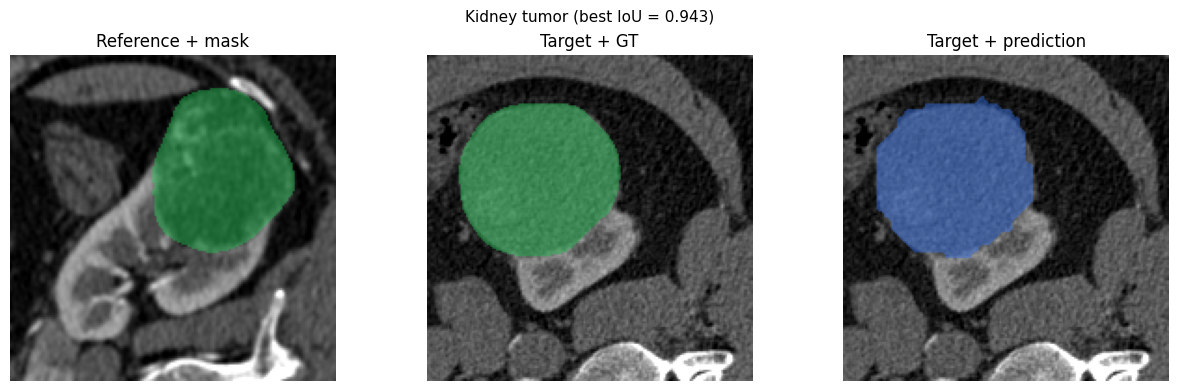

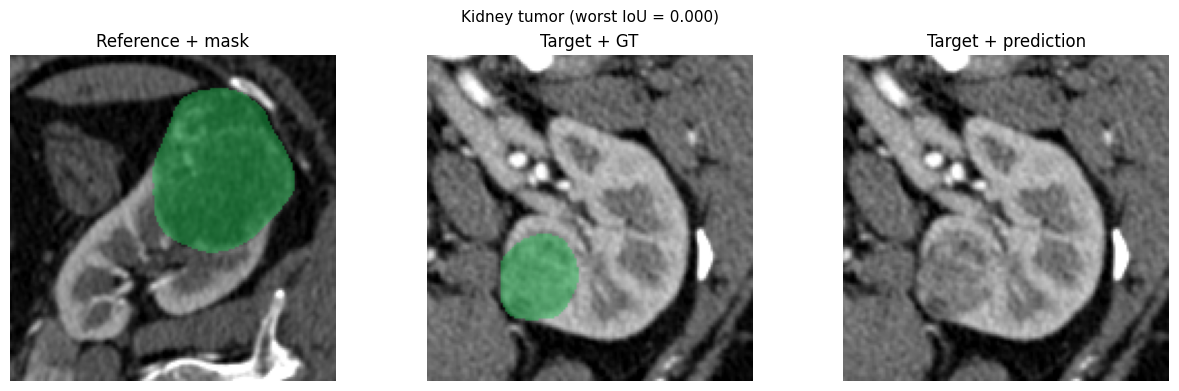

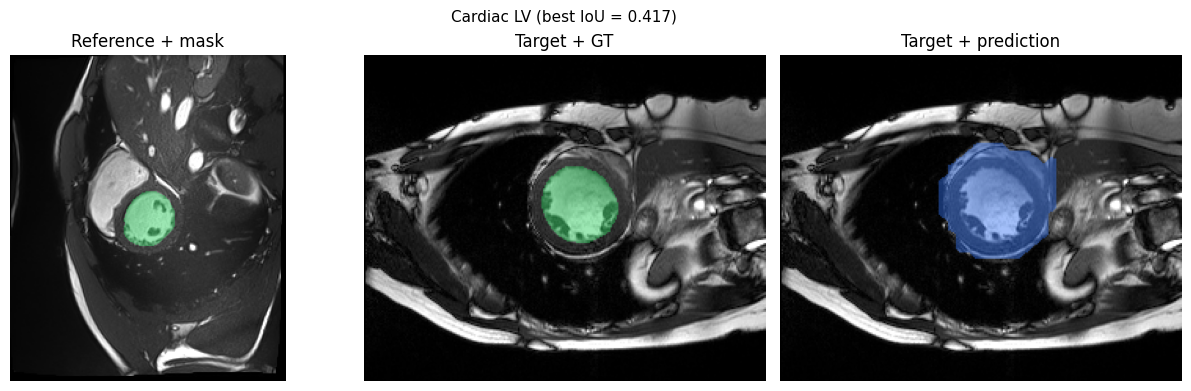

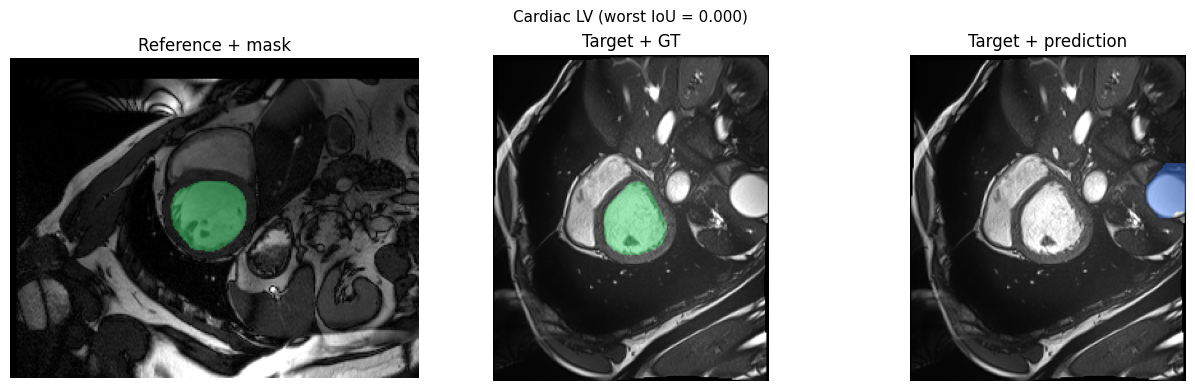

In [20]:
for name in found:
    pairs = load_paired_index(processed_root, name)
    _show_triple(name, domains[name]["ranked"][0], pairs, "best")
    _show_triple(name, domains[name]["ranked"][-1], pairs, "worst")

In [23]:
# KiPA image resolution ablation.
import json
from pathlib import Path

ABLATION_SIZE = 1024
ablation_root = Path(DRIVE_ROOT) / "results" / "kidney_tumor_1024"
metrics_768 = Path(DRIVE_ROOT) / "results" / "kidney_tumor" / "metrics.json"
metrics_1024 = ablation_root / "kidney_tumor" / "metrics.json"

if not metrics_768.is_file():
    raise FileNotFoundError("Run section 2 for kidney_tumor at 768 first.")

row_768 = json.loads(metrics_768.read_text())
row_1024 = json.loads(metrics_1024.read_text()) if metrics_1024.is_file() else None
already = (
    row_1024 is not None
    and int(row_1024.get("image_size", 0)) == ABLATION_SIZE
    and int(row_1024.get("n", 0)) == int(row_768["n"])
)

if already:
    print("skip kidney_tumor @ 1024 (already on Drive)")
else:
    log = "/tmp/insid3_eval_kidney_tumor_1024.log"
    print(f"kidney_tumor @ {ABLATION_SIZE} → {log}")
    !python src/run_insid3.py --dataset kidney_tumor \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {ablation_root} \
      --model-size {MODEL_SIZE} --image-size {ABLATION_SIZE} --seed {SEED} --device cuda \
      > {log}

row_1024 = json.loads(metrics_1024.read_text())
print(f"{'size':<8} {'n':>5} {'mIoU':>7} {'Dice':>7}")
print(f"{'768':<8} {int(row_768['n']):5d} {100 * row_768['mIoU']:6.1f}  {100 * row_768['Dice']:6.1f}")
print(f"{'1024':<8} {int(row_1024['n']):5d} {100 * row_1024['mIoU']:6.1f}  {100 * row_1024['Dice']:6.1f}")
print(f"Δ mIoU = {100 * (row_1024['mIoU'] - row_768['mIoU']):+.1f}")

kidney_tumor @ 1024 → /tmp/insid3_eval_kidney_tumor_1024.log
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main
kidney_tumor: 100% 600/600 [06:04<00:00,  1.65it/s]
size         n    mIoU    Dice
768        600   30.9    43.7
1024       600   32.3    45.1
Δ mIoU (1024 − 768) = +1.4


**Cardiac debias ablation.** INSID3 always debiases for segmentation: it projects DINOv3 features off a positional subspace estimated from a noise image, then matches the reference in that space ([Cuttano et al., CVPR 2026](#ref-cuttano2026)). That removes “same coordinates match across images.” On a short-axis frame the LV often sits in a stable place relative to the RV, so that prior may be the only chamber cue a 1-shot mask has left. The next cell reruns the **same** 600 cardiac episodes at 768 with `--no-debiased` under `results/cardiac_nodebiased/`. It is not the headline table.

INSID3 cannot take LV+RV+MYO as one in-context concept. `set_reference` stacks shots of a **single binary class** and averages their prototypes. Three independent binary runs are not mutual exclusion, and stacking the three masks as “multi-shot” would mix three concepts into one prototype.

In [ ]:
# Cardiac positional-debias ablation (not the headline table).
import json
from pathlib import Path

ablation_root = Path(DRIVE_ROOT) / "results" / "cardiac_nodebiased"
metrics_on = Path(DRIVE_ROOT) / "results" / "cardiac" / "metrics.json"
metrics_off = ablation_root / "cardiac" / "metrics.json"

if not metrics_on.is_file():
    raise FileNotFoundError("Run section 2 for cardiac (debiased, 768) first.")

row_on = json.loads(metrics_on.read_text())
row_off = json.loads(metrics_off.read_text()) if metrics_off.is_file() else None
already = (
    row_off is not None
    and row_off.get("debiased") is False
    and int(row_off.get("n", 0)) == int(row_on["n"])
    and int(row_off.get("image_size", 0)) == int(IMAGE_SIZE)
    and int(row_off.get("seed", -1)) == int(SEED)
)

if already:
    print("skip cardiac --no-debiased (already on Drive)")
else:
    log = "/tmp/insid3_eval_cardiac_nodebiased.log"
    print(f"cardiac --no-debiased → {log}")
    !python src/run_insid3.py --dataset cardiac \
      --input-dir {DRIVE_ROOT}/processed \
      --output-dir {ablation_root} \
      --model-size {MODEL_SIZE} --image-size {IMAGE_SIZE} --seed {SEED} \
      --no-debiased --device cuda \
      > {log}

row_off = json.loads(metrics_off.read_text())
print(f"{'debias':<12} {'n':>5} {'mIoU':>7} {'Dice':>7}")
print(f"{'on (head)':<12} {int(row_on['n']):5d} {100 * row_on['mIoU']:6.1f}  {100 * row_on['Dice']:6.1f}")
print(f"{'off':<12} {int(row_off['n']):5d} {100 * row_off['mIoU']:6.1f}  {100 * row_off['Dice']:6.1f}")
print(f"Δ mIoU (off − on) = {100 * (row_off['mIoU'] - row_on['mIoU']):+.1f}")

**Interpretation**

- **Table.** mIoU / Dice / median on these three tasks. ISIC 54.4 and CXR 78.8 are published scores on *other* tasks — a magnitude scale, not clinical analogues.
- **Boxplot.** Each point is one episode. A box near 0 is many failed episodes, not a uniformly “hard anatomy.”
- **Size vs IoU.** Spearman \(r_s\) asks whether larger targets score higher. Kidney tumor has the strongest link; cardiac stays low across the area range, so the LV failure is not a small-object effect.
- **Overlays.** Green = GT, blue = prediction. On cardiac, look whether the worst cases hit the RV, the whole heart, or nothing.
- **Resolution ablation (KiPA only).** DINOv3 ViT-L/16 is patch-16: 768 px is a 48×48 token grid, 1024 px is 64×64. Kidney tumors are small foci on a full axial slice, so a lesion can occupy only a few tokens at 768 — that leaves the 0.31 mIoU ambiguous (method vs resolution). Colon polyps already fill much of an endoscopy frame; the LV cavity is large and still fails. Extra tokens would not change those two readings. The KiPA cell writes `results/kidney_tumor_1024/` so the 768 run is not overwritten.
- **Debias ablation (cardiac only).** Headline cardiac uses INSID3’s positional correction. `--no-debiased` tests whether that correction deletes the LV-vs-RV location cue. A large gain means the frozen encoder was using “where” more than “what.” A null means the failure is appearance (two blood pools), not debias. Not merged into the headline table.

<h2 id="sec-inspect">4. Browse one domain (interactive)</h2>

Set `DATASET` below to browse one domain. The slider does **not** persist on GitHub. It is for live Colab inspection after [section 2](#sec-eval). Rank 0 is the best IoU. 

cardiac: 600 episodes from /content/drive/MyDrive/insid3-medical-benchmark/results/cardiac/metrics.json
cardiac  rank 1/600  ep 24: patient062 → patient009  IoU=0.417  Dice=0.589


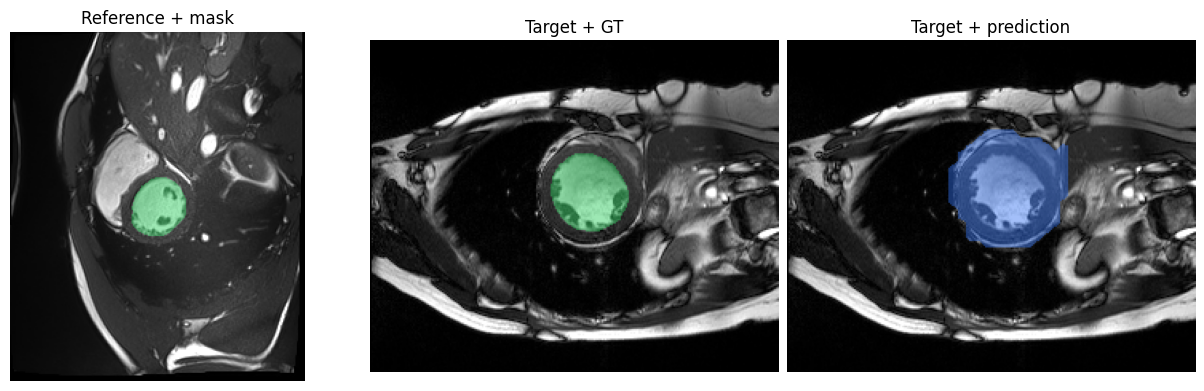

In [21]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from ipywidgets import IntSlider, interact

from src.datasets.episodes import load_paired_index

DATASET = "cardiac"  # polyp | kidney_tumor | cardiac

_pairs = load_paired_index(Path(DRIVE_ROOT) / "processed", DATASET)
_metrics_path = Path(DRIVE_ROOT) / "results" / DATASET / "metrics.json"
_pred_dir = Path(DRIVE_ROOT) / "results" / DATASET / "preds"


def _overlay(image: np.ndarray, mask: np.ndarray, color: tuple[float, float, float]) -> np.ndarray:
    out = image.astype(np.float32).copy()
    tint = np.array(color, dtype=np.float32) * 255.0
    out[mask] = 0.55 * out[mask] + 0.45 * tint
    return np.clip(out, 0, 255).astype(np.uint8)


def _load_metrics():
    if not _metrics_path.is_file():
        raise FileNotFoundError(f"{_metrics_path} missing — run section 2 for DATASET={DATASET!r}.")
    payload = json.loads(_metrics_path.read_text())
    items = sorted(payload["items"], key=lambda row: row["IoU"], reverse=True)
    return payload, items


def show_episode(rank: int = 0):
    """rank=0 is the best IoU. GT masks are green; prediction is blue."""
    payload, items = _load_metrics()
    row = items[int(rank)]
    ref_id, tgt_id = row["reference_id"], row["target_id"]
    pred_path = _pred_dir / f"{int(row['episode_index']):04d}_{tgt_id}.png"
    ref_img, ref_mask = _pairs[ref_id]
    tgt_img, tgt_mask = _pairs[tgt_id]

    print(
        f"{payload.get('dataset')}  rank {int(rank)+1}/{len(items)}  "
        f"ep {row['episode_index']}: {ref_id} → {tgt_id}  "
        f"IoU={row['IoU']:.3f}  Dice={row['Dice']:.3f}"
    )

    ref_np = np.array(Image.open(ref_img).convert("RGB"))
    ref_gt = np.array(Image.open(ref_mask).convert("L")) > 0
    target_np = np.array(Image.open(tgt_img).convert("RGB"))
    gt = np.array(Image.open(tgt_mask).convert("L")) > 0
    pred = np.array(Image.open(pred_path).convert("L")) > 0

    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
    axes[0].imshow(_overlay(ref_np, ref_gt, (0.15, 0.8, 0.35)))
    axes[0].set_title("Reference + mask")
    axes[1].imshow(_overlay(target_np, gt, (0.15, 0.8, 0.35)))
    axes[1].set_title("Target + GT")
    axes[2].imshow(_overlay(target_np, pred, (0.2, 0.45, 0.95)))
    axes[2].set_title("Target + prediction")
    for ax in axes:
        ax.axis("off")
    plt.show()
    plt.close(fig)


payload, items = _load_metrics()
print(f"{DATASET}: {len(items)} episodes from {_metrics_path}")
show_episode(0)

In [22]:
# Drag to browse the current DATASET. 0 = best IoU. Does not persist on GitHub.
_, items = _load_metrics()
interact(
    show_episode,
    rank=IntSlider(min=0, max=max(len(items) - 1, 0), step=1, value=0, description="best→worst"),
)

interactive(children=(IntSlider(value=0, description='best→worst', max=599), Output()), _dom_classes=('widget-…

<function __main__.show_episode(rank: int = 0)>

<h2 id="sec-refs">References</h2>

<p id="ref-cuttano2026">[1] C. Cuttano, G. Trivigno, C. Reich, D. Cremers, C. Masone, and S. Roth. INSID3: Training-free in-context segmentation with DINOv3. In <em>Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)</em>, 2026. <a href="https://visinf.github.io/INSID3/">project page</a>.</p>

<p id="ref-simeoni2025">[2] O. Siméoni, H. V. Vo, M. Seitzer, F. Baldassarre, M. Oquab, C. Jose, V. Khalidov, M. Szafraniec, S. Yi, M. Ramamonjisoa, et al. DINOv3. <em>arXiv preprint arXiv:2508.10104</em>, 2025.</p>

<p id="ref-jha2020">[3] D. Jha, P. H. Smedsrud, M. A. Riegler, P. Halvorsen, T. de Lange, D. Johansen, and H. D. Johansen. Kvasir-SEG: A segmented polyp dataset. In <em>International Conference on Multimedia Modeling (MMM)</em>, 2020. <a href="https://datasets.simula.no/kvasir-seg/">Kvasir-SEG</a>.</p>

<p id="ref-he2021">[4] Y. He, G. Yang, J. Yang, R. Chen, J. L. Coatrieux, and S. Li. Dense biased networks with deep priori anatomy and hard region adaptation: Semi-supervised learning for fine renal artery segmentation. <em>Medical Image Analysis</em>, 2021. Training data: <a href="https://kipa22.grand-challenge.org/">KiPA22</a>.</p>

<p id="ref-bernard2018">[5] O. Bernard, A. Lalande, C. Zotti, F. Cervenansky, X. Yang, P.-A. Heng, I. Cetin, K. Lekadir, O. Camara, M. A. Gonzalez Ballester, et al. Deep learning techniques for automatic MRI cardiac multi-structures segmentation and diagnosis: Is the problem solved? <em>IEEE Transactions on Medical Imaging</em>, 2018. <a href="https://www.creatis.insa-lyon.fr/Challenge/acdc/">ACDC</a>.</p>